# lab1.2


---


## 📋 Table of Contents
1. [Introduction]
2. Import Libraries & Load Data
3. Dataset Overview
4. Missing Value Analysis

---

## 1. Introduction
The Taxi Price Regression dataset is a classic and widely-used dataset in the field of machine learning regression tasks. It focuses on predicting the continuous target variable—taxi trip fares—based on multiple contextual and spatial features of taxi trips. This dataset provides a realistic simulation of urban transportation pricing scenarios, offering a valuable opportunity to explore feature engineering, regression modeling, and data preprocessing techniques in real-world applications.
### 🎯 Objective
In this notebook, we perform a thorough Exploratory Data Analysis (EDA) to uncover the key factors influencing taxi trip fares and build a robust regression model for fare prediction. We answer questions like:
How does trip distance impact the total fare amount?
Do traffic conditions and weather conditions affect pricing trends?
What role does trip duration play in fare calculation?
Which features are most critical for accurate taxi fare prediction?
This notebook is designed as a complete beginner's guide — every step is explained clearly with visualizations, statistical analyses, and actionable insights to help you master the fundamentals of regression problem-solving.
### 📦 Dataset Columns

| Column | Description |
| --- | --- |
| Distance (km) | The total length of the taxi trip in kilometers |
| Pickup Time | The exact start time of the trip (datetime format) |
| Dropoff Time | The exact end time of the trip (datetime format) |
| Traffic Condition | Categorical indicator of traffic status (light, medium, heavy) |
| Passenger Count | Number of passengers traveling in the taxi |
| Weather Condition | Categorical data of weather during the trip (clear, rain, snow) |
| Trip Duration (minutes) | Total time elapsed for the trip in minutes |
| Fare Amount (target) | The total cost of the taxi trip in US dollars (value to predict) |

### 📊 Dataset Highlights
Contains 1,000+ rows of synthetic data, providing a sufficient sample size for model training and validation.
Includes realistic missing values and outliers to simulate real-world data preprocessing challenges.
Features built-in correlations between key variables (e.g., distance and trip duration) to mimic actual urban transportation patterns.
Ideal for regression analysis, feature selection, and feature engineering exercises, serving as a standard benchmark for regression model performance comparison.
### 🚕 Possible Applications
Predicting taxi fare amounts based on trip distance, traffic conditions, and weather factors.
Analyzing the impact of time of day and seasonal conditions on taxi pricing trends.
Building and comparing multiple regression models (e.g., Linear Regression, Random Forest Regressor) to optimize prediction accuracy.
Exploring feature importance to identify core factors that drive taxi fare calculations.
Get started by loading the data, conducting exploratory analysis, engineering meaningful features, and building regression models to optimize taxi fare predictions. Good luck!

## 2. Import Libraries & Load Data

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import os
import torch
# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Settings
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

import warnings
warnings.filterwarnings('ignore')

print('Libraries imported successfully!')

Libraries imported successfully!


In [2]:
# Load data
df = pd.read_csv('./taxi_trip_pricing.csv')

print(f'Dataset shape: {df.shape}')
print(f'Rows: {df.shape[0]} | Columns: {df.shape[1]}')
df.head()

Dataset shape: (1000, 11)
Rows: 1000 | Columns: 11


,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,Morning,Weekday,3.0,Low,Clear,3.56,0.80,0.32,53.82,36.2624
1,47.59,Afternoon,Weekday,1.0,High,Clear,NaN,0.62,0.43,40.57,NaN
2,36.87,Evening,Weekend,1.0,High,Clear,2.70,1.21,0.15,37.27,52.9032
3,30.33,Evening,Weekday,4.0,Low,NaN,3.48,0.51,0.15,116.81,36.4698
4,NaN,Evening,Weekday,3.0,High,Clear,2.93,0.63,0.32,22.64,15.6180


## 3. Dataset Overview

Let's get a high-level understanding of the dataset — data types, basic statistics, and structure.

In [3]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       950 non-null    float64
 1   Time_of_Day            950 non-null    object 
 2   Day_of_Week            950 non-null    object 
 3   Passenger_Count        950 non-null    float64
 4   Traffic_Conditions     950 non-null    object 
 5   Weather                950 non-null    object 
 6   Base_Fare              950 non-null    float64
 7   Per_Km_Rate            950 non-null    float64
 8   Per_Minute_Rate        950 non-null    float64
 9   Trip_Duration_Minutes  950 non-null    float64
 10  Trip_Price             951 non-null    float64
dtypes: float64(7), object(4)
memory usage: 86.1+ KB


In [4]:
# Statistical summary
df.describe().round(2)

,Trip_Distance_km,Passenger_Count,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
count,950.00,950.00,950.00,950.00,950.00,950.00,951.00
mean,27.07,2.48,3.50,1.23,0.29,62.12,56.87
std,19.91,1.10,0.87,0.43,0.12,32.15,40.47
min,1.23,1.00,2.01,0.50,0.10,5.01,6.13
25%,12.63,1.25,2.73,0.86,0.19,35.88,33.74
50%,25.83,2.00,3.52,1.22,0.29,61.86,50.07
75%,38.40,3.00,4.26,1.61,0.39,89.06,69.10
max,146.07,4.00,5.00,2.00,0.50,119.84,332.04


In [5]:
# Categorical columns summary
df.describe(include='object')

,Time_of_Day,Day_of_Week,Traffic_Conditions,Weather
count,950,950,950,950
unique,4,2,3,3
top,Afternoon,Weekday,Low,Clear
freq,371,655,397,667


## 4. Missing Value Analysis

Before any analysis, we must understand where data is missing. Missing values can heavily influence our conclusions if not handled properly.

In [6]:
# Missing value counts and percentages
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2)
})
missing = missing[missing['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print(missing)

                       Missing Count  Missing %
Trip_Distance_km                  50        5.0
Time_of_Day                       50        5.0
Day_of_Week                       50        5.0
Passenger_Count                   50        5.0
Traffic_Conditions                50        5.0
Weather                           50        5.0
Base_Fare                         50        5.0
Per_Km_Rate                       50        5.0
Per_Minute_Rate                   50        5.0
Trip_Duration_Minutes             50        5.0
Trip_Price                        49        4.9


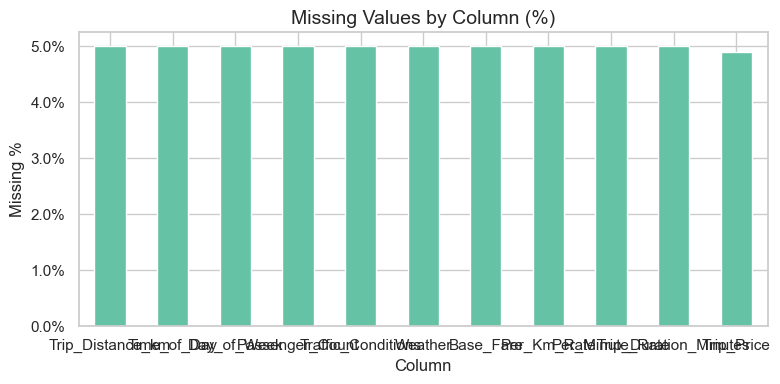

In [7]:
# Visualize missing values
fig, ax = plt.subplots(figsize=(8, 4))
missing['Missing %'].plot(kind='bar', color=sns.color_palette('Set2')[0], ax=ax)
ax.set_title('Missing Values by Column (%)')
ax.set_xlabel('Column')
ax.set_ylabel('Missing %')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 5.Data Preprocessing

In [8]:
#特征处理
df=pd.concat([df,
             pd.get_dummies(df['Time_of_Day']).astype(int),
             pd.get_dummies(df['Day_of_Week'],prefix='Embarked').astype(int),
             pd.get_dummies(df['Traffic_Conditions'],prefix='class').astype(int),
             pd.get_dummies(df['Weather'],prefix='class').astype(int)], axis=1)
df.head()


,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price,Afternoon,Evening,Morning,Night,Embarked_Weekday,Embarked_Weekend,class_High,class_Low,class_Medium,class_Clear,class_Rain,class_Snow
0,19.35,Morning,Weekday,3.0,Low,Clear,3.56,0.80,0.32,53.82,36.2624,0,0,1,0,1,0,0,1,0,1,0,0
1,47.59,Afternoon,Weekday,1.0,High,Clear,NaN,0.62,0.43,40.57,NaN,1,0,0,0,1,0,1,0,0,1,0,0
2,36.87,Evening,Weekend,1.0,High,Clear,2.70,1.21,0.15,37.27,52.9032,0,1,0,0,0,1,1,0,0,1,0,0
3,30.33,Evening,Weekday,4.0,Low,NaN,3.48,0.51,0.15,116.81,36.4698,0,1,0,0,1,0,0,1,0,0,0,0
4,NaN,Evening,Weekday,3.0,High,Clear,2.93,0.63,0.32,22.64,15.6180,0,1,0,0,1,0,1,0,0,1,0,0


In [9]:
#缺失值处理
df['Trip_Distance_km']=df['Trip_Distance_km'].fillna(df.Trip_Distance_km.mean())
df['Passenger_Count']=df['Passenger_Count'].fillna(df.Passenger_Count.mean())
df['Base_Fare']=df['Base_Fare'].fillna(df.Base_Fare.mean())
df['Per_Km_Rate']=df['Per_Km_Rate'].fillna(df.Per_Km_Rate.mean())
df['Per_Minute_Rate']=df['Per_Minute_Rate'].fillna(df.Per_Minute_Rate.mean())
df['Trip_Duration_Minutes']=df['Trip_Duration_Minutes'].fillna(df.Trip_Duration_Minutes.mean())
df['Trip_Price']=df['Trip_Price'].fillna(df.Trip_Price.mean())



In [10]:
df.head()

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price,Afternoon,Evening,Morning,Night,Embarked_Weekday,Embarked_Weekend,class_High,class_Low,class_Medium,class_Clear,class_Rain,class_Snow
0,19.350000,Morning,Weekday,3.0,Low,Clear,3.560000,0.80,0.32,53.82,36.262400,0,0,1,0,1,0,0,1,0,1,0,0
1,47.590000,Afternoon,Weekday,1.0,High,Clear,3.502989,0.62,0.43,40.57,56.874773,1,0,0,0,1,0,1,0,0,1,0,0
2,36.870000,Evening,Weekend,1.0,High,Clear,2.700000,1.21,0.15,37.27,52.903200,0,1,0,0,0,1,1,0,0,1,0,0
3,30.330000,Evening,Weekday,4.0,Low,NaN,3.480000,0.51,0.15,116.81,36.469800,0,1,0,0,1,0,0,1,0,0,0,0
4,27.070547,Evening,Weekday,3.0,High,Clear,2.930000,0.63,0.32,22.64,15.618000,0,1,0,0,1,0,1,0,0,1,0,0


In [11]:
#删除多余数据
df_clean=df.drop(['Time_of_Day','Day_of_Week','Traffic_Conditions','Weather',],axis=1)
df_clean.head()


,Trip_Distance_km,Passenger_Count,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price,Afternoon,Evening,Morning,Night,Embarked_Weekday,Embarked_Weekend,class_High,class_Low,class_Medium,class_Clear,class_Rain,class_Snow
0,19.350000,3.0,3.560000,0.80,0.32,53.82,36.262400,0,0,1,0,1,0,0,1,0,1,0,0
1,47.590000,1.0,3.502989,0.62,0.43,40.57,56.874773,1,0,0,0,1,0,1,0,0,1,0,0
2,36.870000,1.0,2.700000,1.21,0.15,37.27,52.903200,0,1,0,0,0,1,1,0,0,1,0,0
3,30.330000,4.0,3.480000,0.51,0.15,116.81,36.469800,0,1,0,0,1,0,0,1,0,0,0,0
4,27.070547,3.0,2.930000,0.63,0.32,22.64,15.618000,0,1,0,0,1,0,1,0,0,1,0,0


In [12]:
# 数据切分
labels=df_clean['Trip_Price'].to_numpy()

df_clean=df_clean.drop(['Trip_Price'],axis=1)
data=df_clean.to_numpy()

feature_names=list(df_clean.columns)

np.random.seed(10)
train_indices=np.random.choice(len(labels),int(0.7*len(labels)),replace=False)
test_indices=list(set(range(len(labels)))-set(train_indices))


train_features=data[train_indices]
train_labels=labels[train_indices]
test_features=data[test_indices]
test_labels=labels[test_indices]




In [13]:
df_clean.head()

,Trip_Distance_km,Passenger_Count,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Afternoon,Evening,Morning,Night,Embarked_Weekday,Embarked_Weekend,class_High,class_Low,class_Medium,class_Clear,class_Rain,class_Snow
0,19.350000,3.0,3.560000,0.80,0.32,53.82,0,0,1,0,1,0,0,1,0,1,0,0
1,47.590000,1.0,3.502989,0.62,0.43,40.57,1,0,0,0,1,0,1,0,0,1,0,0
2,36.870000,1.0,2.700000,1.21,0.15,37.27,0,1,0,0,0,1,1,0,0,1,0,0
3,30.330000,4.0,3.480000,0.51,0.15,116.81,0,1,0,0,1,0,0,1,0,0,0,0
4,27.070547,3.0,2.930000,0.63,0.32,22.64,0,1,0,0,1,0,1,0,0,1,0,0


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F 

# 设置随机种子
torch.manual_seed(0)


class RMSLELoss(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, y_hat, y_true):
         ------------------------------------------------------------------------
        #TODO

# 定义ThreelinearModel模型
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.criterion = RMSLELoss()  # 回归任务专用损失
        # 定义三个线性层，用于处理输入特征
        ------------------------------------------------------------------------
        #TODO
        

    def forward(self, x):
         ------------------------------------------------------------------------
        #TODO

    def getloss(self, x, y):
        y_pred = self.forward(x)
        return self.criterion(y_pred, y)
   


## 训练与测试

我们将训练一个 epoch 的代码封装在`train_epoch`函数中，其中流程如下：

1. 遍历训练集，将数据输入模型，得到预测值；
2. 计算预测值与真实值之间的差值，然后计算损失；
3. 通过反向传播更新模型参数。
4. 返回训练集上的平均损失。

然后我们实现了一个`eval_model`函数来评估模型的性能：




In [ ]:

if __name__ == '__main__':
    # 创建 ThreelinearModel 的神经网络模型
    net = MLP()
    # 设置训练轮数为200次，选择Adam优化器，学习率为0.04
    num_epochs = 100
    optimizer = torch.optim.Adam(net.parameters(), lr=0.005)
    
    # 将训练数据转换为PyTorch张量格式
    input_train_tensor = torch.from_numpy(train_features).type(torch.float32)
    label_train_tensor = torch.from_numpy(train_labels).type(torch.float32)
    
    input_test_tensor = torch.from_numpy(test_features).type(torch.float32)
    label_test_tensor = torch.from_numpy(test_labels).type(torch.float32)
    

    # 用于存储每轮训练的损失值
    losses_train = []
    losses_test = []
    
    # 开始训练循环
    for epoch in range(num_epochs):
        # 计算当前模型在训练数据上的损失值
         ------------------------------------------------------------------------
        #TODO
        # 记录损失值
         ------------------------------------------------------------------------
        #TODO
        # 清零梯度，防止梯度累积
         ------------------------------------------------------------------------
        #TODO
        # 反向传播，计算梯度
         ------------------------------------------------------------------------
        #TODO
        # 更新模型参数
         ------------------------------------------------------------------------
        #TODO
        # 每20轮打印一次训练损失
        if epoch % 20 == 0:
            print('Epoch {}/{} => Train_Loss: {:.2f}. Test_Loss:{:.2f}'.format(epoch + 1, num_epochs, loss_train.item(), loss_test.item()))
    
    # 创建'models'文件夹（如果不存在），保存训练好的模型参数
    os.makedirs('models1', exist_ok=True)
    torch.save(net.state_dict(), 'models/titanic_model.pt')




Epoch 1/100 => Train_Loss: 4.18. Test_Loss:4.16
Epoch 21/100 => Train_Loss: 0.55. Test_Loss:0.57
Epoch 41/100 => Train_Loss: 0.56. Test_Loss:0.59
Epoch 61/100 => Train_Loss: 0.55. Test_Loss:0.57
Epoch 81/100 => Train_Loss: 0.54. Test_Loss:0.57


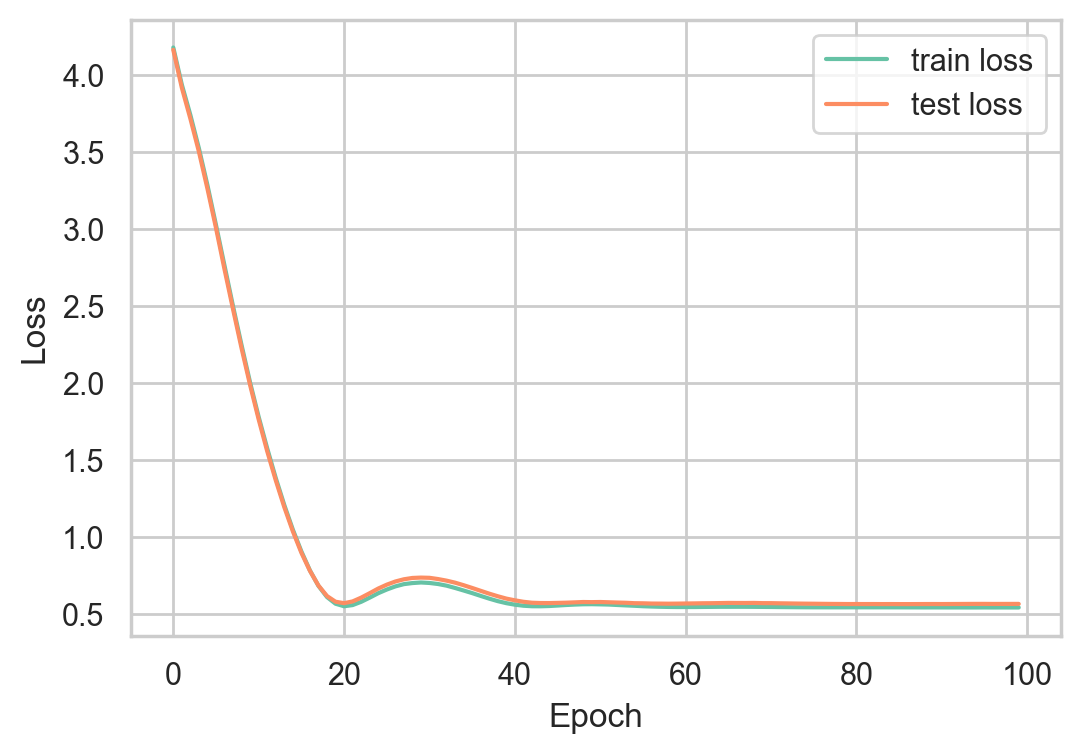

In [19]:
import matplotlib.pyplot as plt
%config InlineBackend.figure_format='retina'
plt.figure(figsize=(6, 4))
plt.plot(losses_train, label="train loss")
plt.plot(losses_test, label="test loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()